In [62]:
import numpy as np
from core import Simulation
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n = 5

# Each node has a population of 100,000
populations = np.full(n, 1e5)

# Seed 0.1% infection in node 0; rest fully susceptible
S0 = np.array([0.999, 1.0, 1.0, 1.0, 1.0]) * 1e5
I0 = np.array([0.001, 0.0, 0.0, 0.0, 0.0]) * 1e5
R0 = np.zeros(n)
init_state = np.concatenate([S0, I0, R0])

# Asymmetric commuter matrix; zero diagonal; rows sum to 0.1
C = rng.uniform(0, 1, size=(n, n))

sim = Simulation(
    populations=populations,
    init_state=init_state,
    connection_matrix=C,
    infection_rate=0.1,       
    recovery_rate=1000,        
    social_connectivity=2,
)
sim.solve_system(t_end=360*2) 
t, S, I, R = sim.get_results()

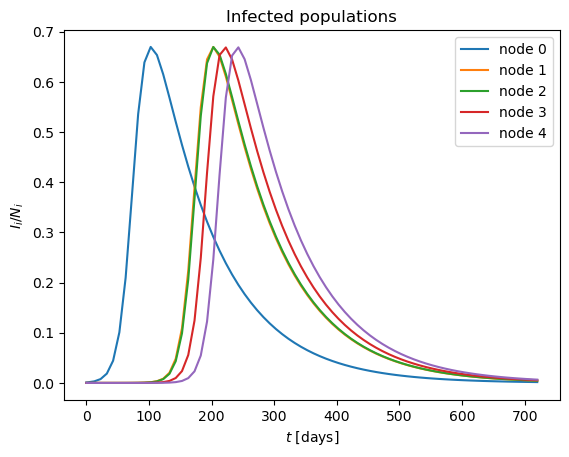

In [65]:
for (i, I_i) in enumerate(I):
    plt.plot(t, I_i / 1e5, label = f'node {i}')
    
plt.title('Infected populations')
plt.xlabel('$t$ [days]')
plt.ylabel('$I_i / N_i$')
plt.legend()